In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv("car_fuel_efficiency_2026.csv")

df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [33]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight',
           'model_year']

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

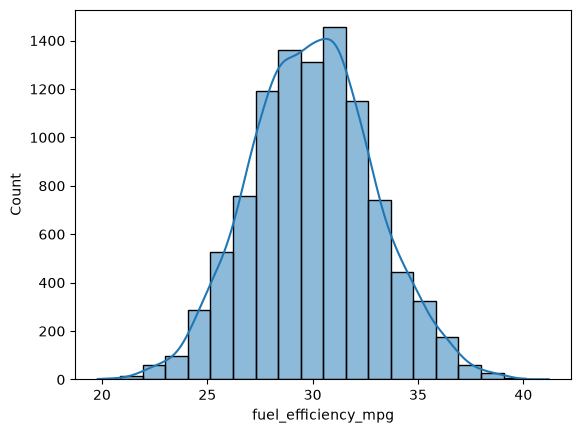

In [34]:
import seaborn as sns

sns.histplot(df['fuel_efficiency_mpg'], bins=20, kde=True)

In [35]:
df[columns].isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
dtype: int64

In [36]:
df[columns]['horsepower'].median()

np.float64(254.0)

In [37]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [38]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack((ones, X))

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    e = y - y_pred
    se = e ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [39]:
X_train_mean = df_train[columns].fillna(df_train.horsepower.mean()).values
X_val_mean = df_val[columns].fillna(df_train.horsepower.mean()).values
X_test_mean = df_test[columns].fillna(df_train.horsepower.mean()).values

X_train_zero = df_train[columns].fillna(0).values
X_val_zero = df_val[columns].fillna(0).values
X_test_zero = df_test[columns].fillna(0).values

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)


In [40]:
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)

round(rmse(y_val, y_pred_mean), 3), round(rmse(y_val, y_pred_zero), 3)

(np.float64(2.202), np.float64(2.205))

In [42]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [44]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)
    y_pred = w0 + X_val_zero.dot(w)
    print(r, round(rmse(y_val, y_pred), 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [46]:
scores = []
for seed in [0,1,2,3,4,5,6,7,8,9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    X_train_zero = df_train[columns].fillna(0).values
    X_val_zero = df_val[columns].fillna(0).values
    X_test_zero = df_test[columns].fillna(0).values

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

    y_pred = w0_zero + X_val_zero.dot(w_zero)
    scores.append(round(rmse(y_val, y_pred), 3))
    print(seed, round(rmse(y_val, y_pred), 3))

scores = np.array(scores)
print(round(scores.std(),3))


0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207
0.029


In [48]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
df_train = pd.concat([df_train, df_val]).reset_index(drop=True)

X_train_zero = df_train[columns].fillna(0).values
X_test_zero = df_test[columns].fillna(0).values

y_train = df_train['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

w0_zero, w_zero = train_linear_regression_reg(X_train_zero, y_train, r=0.001)
y_pred = w0_zero + X_test_zero.dot(w_zero)

rmse(y_test, y_pred)

np.float64(2.2358277471917636)